# Student Performance: EDA, Regression and Classification

This notebook follows the complete machine learning workflow required for the Student Performance dataset.

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

df = pd.read_csv("Day18_19_student_habits_performance.csv")

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 2. Understand the Dataset

Check the number of rows and columns, column names, data types, and basic summary statistics.

In [2]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe(include="all").T)

Shape: (1000, 16)

Column Names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data Types:
student_id                           str
age                                int64
gender                               str
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                        str
attendance_percentage            float64
sleep_hours                      float64
diet_quality                         str
exercise_frequency                 int64
parental_education_level             str
internet_quality                     str
mental_health_rating               int64
extracurricular_participation        str
exam_score                     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Identify Numerical and Categorical Variables

In [3]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Variables:")
print(numerical_columns)

print("\nCategorical Variables:")
print(categorical_columns)

Numerical Variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical Variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


C:\Users\syedf\AppData\Local\Temp\ipykernel_23732\147876023.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


## 4. Check Missing Values

Identify columns containing missing values and their counts.

In [4]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values:")
display(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:


parental_education_level    91
dtype: int64


Total Missing Values: 91


## 5. Examine Distributions

The exam score distribution is examined first because it is the regression target and is also used to create the Pass/Fail target.

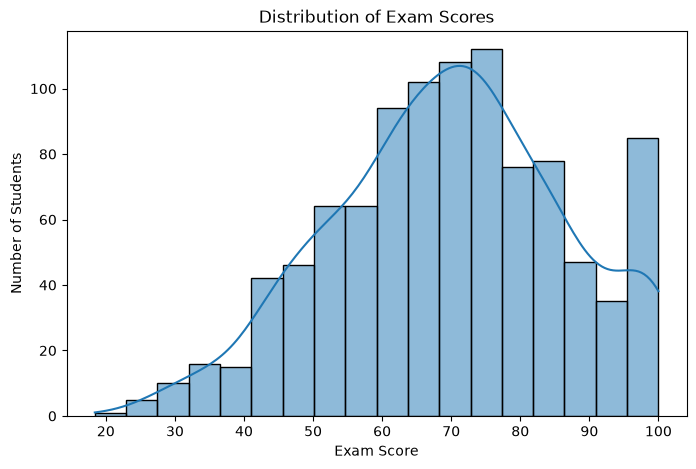

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

## 6. Examine Potential Outliers

Use the IQR method to identify potential outliers in numerical variables. Outliers are identified but not automatically removed because they may represent genuine student observations.

In [6]:
outlier_counts = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_counts[column] = ((df[column] < lower_bound) | 
                              (df[column] > upper_bound)).sum()

outlier_table = pd.DataFrame.from_dict(
    outlier_counts, orient="index", columns=["Potential_Outliers"]
)

display(outlier_table)

,Potential_Outliers
age,0
study_hours_per_day,7
social_media_hours,5
netflix_hours,4
attendance_percentage,3
sleep_hours,2
exercise_frequency,0
mental_health_rating,0
exam_score,2


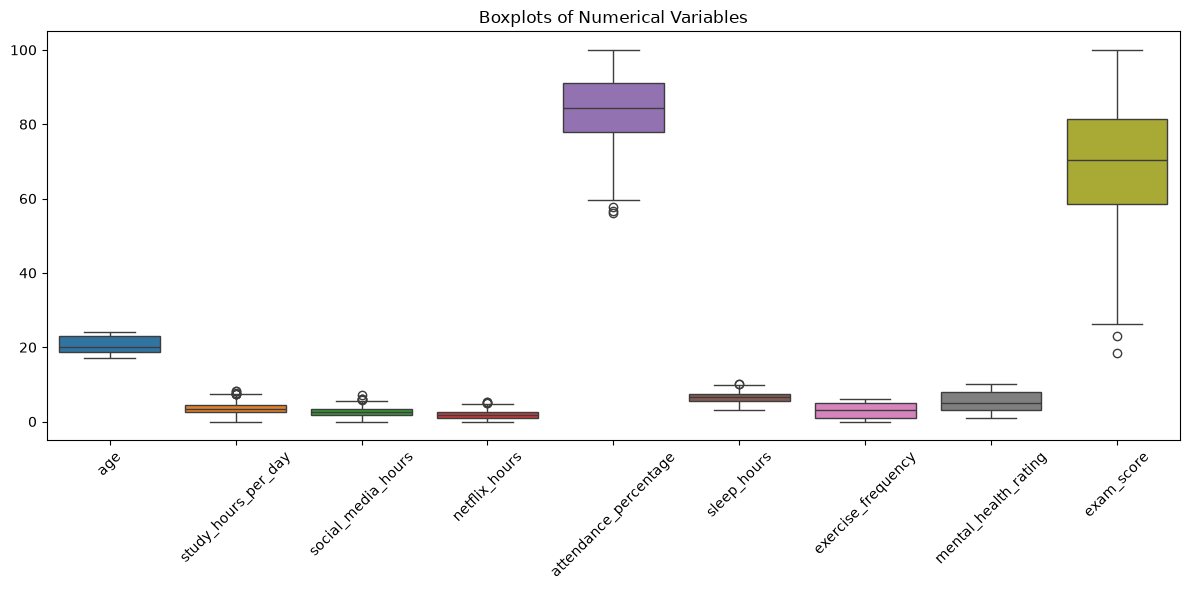

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_columns])
plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Examine Correlations

Correlation is used to identify numerical variables that appear related to `exam_score` and to examine relationships among numerical variables.

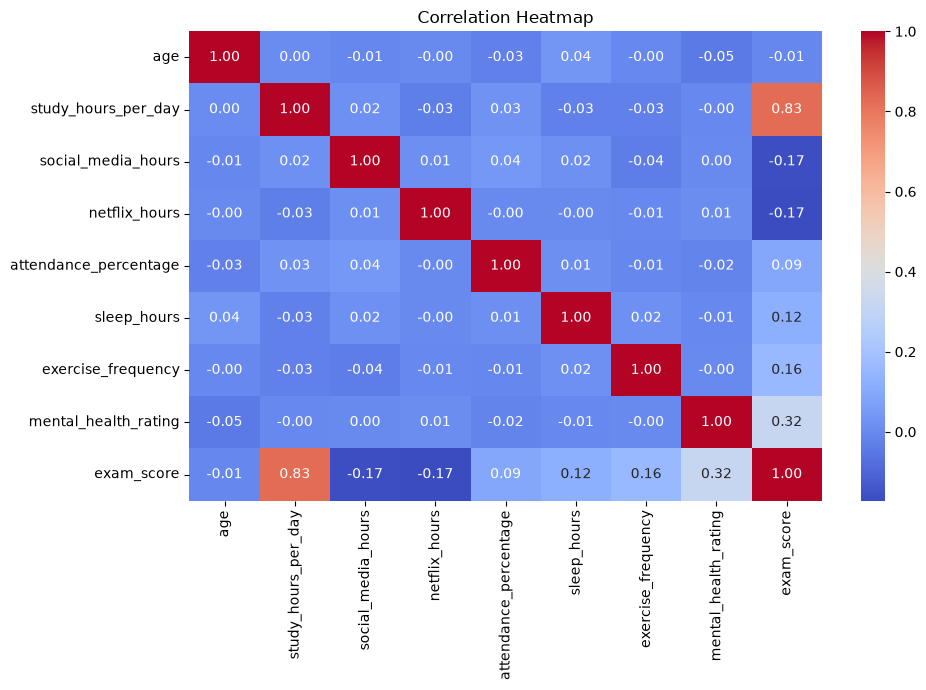

Correlation with exam_score:


,Correlation
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


In [8]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with exam_score:")
display(
    correlation_matrix["exam_score"]
    .sort_values(ascending=False)
    .to_frame("Correlation")
)

## 8. Examine Relationships with Exam Score

Study hours are examined against exam score because the correlation analysis indicates a strong relationship.

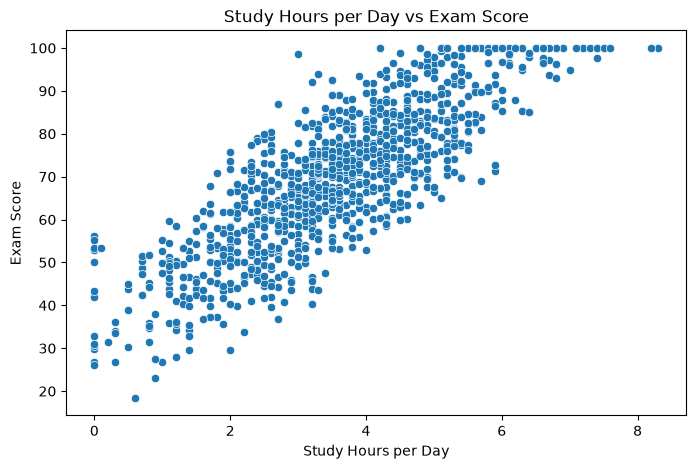

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("Study Hours per Day vs Exam Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.show()

## 9. Compare Exam Scores Across a Categorical Variable

This checks whether exam scores differ across extracurricular participation groups.

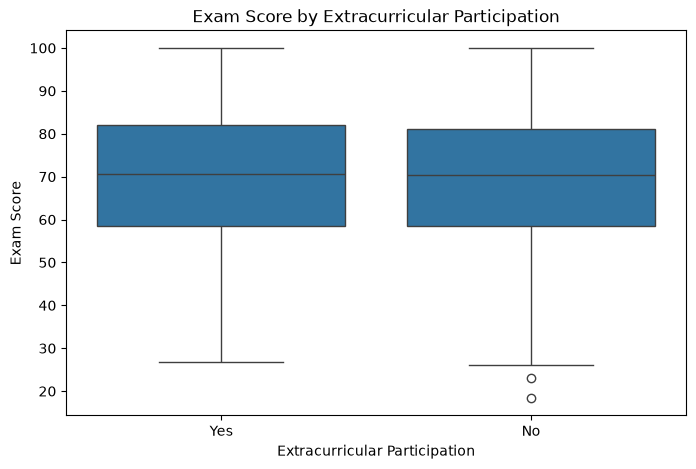

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="extracurricular_participation", y="exam_score")
plt.title("Exam Score by Extracurricular Participation")
plt.xlabel("Extracurricular Participation")
plt.ylabel("Exam Score")
plt.show()

## 10. EDA Findings

- `study_hours_per_day` has the strongest positive numerical relationship with `exam_score`.
- `mental_health_rating` also shows a positive relationship with exam score.
- `social_media_hours` and `netflix_hours` show negative relationships with exam score.
- `exercise_frequency` and `sleep_hours` show smaller positive relationships with exam score.
- The dataset contains missing values only in `parental_education_level`; these will be handled during preprocessing.
- Potential outliers are present in some numerical variables, but they are retained because there is no evidence that they are invalid observations.

## 11. Prepare Data for Machine Learning

`student_id` is excluded because it is an identifier rather than a meaningful predictive feature. `exam_score` is the regression target.

Categorical variables are one-hot encoded and missing values are imputed. Numerical missing values, if any, are filled with the median; categorical missing values are filled with the most frequent category.

In [11]:
X = df.drop(columns=["student_id", "exam_score"])
y = df["exam_score"]

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

print("Features used:", X.columns.tolist())
print("\nRegression target: exam_score")

Features used: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Regression target: exam_score


C:\Users\syedf\AppData\Local\Temp\ipykernel_23732\1320307609.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


## 12. Split the Data into Training and Testing Sets

Use 80% of the data for training and 20% for testing.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 14)
Testing set: (200, 14)


## 13. Train the Linear Regression Model

In [13]:
linear_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_regression.fit(X_train, y_train)

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

## 14. Evaluate the Regression Model

Use Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [14]:
def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2 Score": r2_score(actual, predicted)
    }

regression_results = pd.DataFrame({
    "Training": regression_metrics(y_train, y_train_pred),
    "Testing": regression_metrics(y_test, y_test_pred)
})

display(regression_results)

,Training,Testing
MAE,4.214166,4.192343
RMSE,5.344722,5.150974
R2 Score,0.902108,0.896531


## 15. Create the Pass/Fail Classification Target

A student is classified as:

- **Pass**: `exam_score >= 50`
- **Fail**: `exam_score < 50`

In [15]:
df["pass_fail"] = np.where(df["exam_score"] >= 50, "Pass", "Fail")

print(df["pass_fail"].value_counts())

pass_fail
Pass    869
Fail    131
Name: count, dtype: int64


## 16. Prepare and Split the Classification Data

Use the same prepared predictor variables and exclude both `exam_score` and the newly created `pass_fail` target from the features.

In [16]:
X_class = df.drop(columns=["student_id", "exam_score", "pass_fail"])
y_class = df["pass_fail"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

classification_numerical = X_class.select_dtypes(include=np.number).columns.tolist()
classification_categorical = X_class.select_dtypes(include="object").columns.tolist()

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            classification_numerical
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            classification_categorical
        )
    ]
)

C:\Users\syedf\AppData\Local\Temp\ipykernel_23732\665297269.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  classification_categorical = X_class.select_dtypes(include="object").columns.tolist()


## 17. Train the Classification Model

Logistic Regression is used because Pass/Fail is a binary classification problem.

In [17]:
logistic_regression = Pipeline(
    steps=[
        ("preprocessor", classification_preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

logistic_regression.fit(X_train_class, y_train_class)

y_train_class_pred = logistic_regression.predict(X_train_class)
y_test_class_pred = logistic_regression.predict(X_test_class)

## 18. Evaluate the Classification Model

Evaluate the model using a confusion matrix, accuracy, precision, recall, and F1-score.

In [18]:
print("Testing Confusion Matrix:")
cm = confusion_matrix(y_test_class, y_test_class_pred)
display(pd.DataFrame(
    cm,
    index=["Actual Fail", "Actual Pass"],
    columns=["Predicted Fail", "Predicted Pass"]
))

classification_results = pd.DataFrame({
    "Training": [
        accuracy_score(y_train_class, y_train_class_pred),
        precision_score(y_train_class, y_train_class_pred, pos_label="Pass"),
        recall_score(y_train_class, y_train_class_pred, pos_label="Pass"),
        f1_score(y_train_class, y_train_class_pred, pos_label="Pass")
    ],
    "Testing": [
        accuracy_score(y_test_class, y_test_class_pred),
        precision_score(y_test_class, y_test_class_pred, pos_label="Pass"),
        recall_score(y_test_class, y_test_class_pred, pos_label="Pass"),
        f1_score(y_test_class, y_test_class_pred, pos_label="Pass")
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])

display(classification_results)

Testing Confusion Matrix:


,Predicted Fail,Predicted Pass
Actual Fail,22,4
Actual Pass,4,170


,Training,Testing
Accuracy,0.956250,0.960000
Precision,0.972779,0.977011
Recall,0.976978,0.977011
F1-Score,0.974874,0.977011


## 19. Training vs Testing Performance and Model Fit

Compare the training and testing metrics.

For the regression model, similar training and testing R² scores and errors indicate that the model generalizes reasonably well.

For the classification model, similar training and testing accuracy, precision, recall, and F1-score indicate that there is no strong evidence of overfitting.

A large gap between training and testing performance would suggest overfitting, while low performance on both sets would suggest underfitting.

## 20. Most Important Findings

The EDA shows that study time is the strongest numerical factor associated with exam score. Mental health rating has a positive association, while higher social media and Netflix usage have negative associations. Sleep and exercise show smaller positive relationships. Attendance has a positive but relatively weak numerical correlation in this dataset.

The linear regression model provides a strong fit with similar training and testing performance. The classification model also shows very similar training and testing results, suggesting no major overfitting or underfitting.

## 21. Conclusion: Five Meaningful Insights

1. **Study time is the strongest predictor of exam performance.** Students who spend more hours studying per day tend to achieve higher exam scores.

2. **Mental health is positively associated with academic performance.** Higher mental health ratings are associated with higher exam scores in this dataset.

3. **Higher entertainment and social-media usage is associated with lower scores.** Both social media hours and Netflix hours show negative relationships with exam score.

4. **Healthy routines have smaller positive relationships with performance.** Sleep hours and exercise frequency are positively related to exam scores, although their relationships are weaker than study time.

5. **The models generalize reasonably well.** The training and testing results are close for both regression and classification, so there is no strong evidence of overfitting in these models.